# 02 — 三種寫法比較：手刻迴圈 vs `create_agent`（現成）vs 手刻 `StateGraph`

**這份要學什麼**
- 三種寫法（手刻 while-loop / `create_agent` / 手刻 `StateGraph`）做的是同一件事
- 目前版本的 `AgentExecutor` 已經被移除，`create_agent` 是現在的官方入口
- `create_agent` 底層其實是編譯出一個 `StateGraph`

> **這份 notebook 完全不需要 API key。** 所有範例都用 `_llm.scripted_model()`——一個事先寫好「第幾次呼叫要回什麼」的假模型，讓整條 agent 迴圈可以離線、確定性地完整跑一遍。你會看到跟真的 LLM 一樣結構的 `AIMessage` / `ToolMessage` 序列，只是內容是照劇本走的。想接真模型的話，最後留了一個「有 API key 才跑」的對照 cell。

## 版本現況說明

原本規劃是比較「舊版 `AgentExecutor`」vs「LangGraph 寫法」，但目前這個 repo 裝的 `langchain==1.4.0` 已經把舊的 `AgentExecutor` 整個移除了（`from langchain.agents import AgentExecutor` 會直接 `ImportError`）。現在 LangChain 官方的 `create_agent()` 底層本來就是編譯出一個 LangGraph 的 `StateGraph`。也就是說，「LangChain agent」跟「LangGraph agent」現在已經不是兩個世界的東西——差別只在於「你想讓框架幫你做多少事」。

所以這份 notebook 改成更貼近現況的三種寫法比較：

| Tier | 這裡怎麼做 | 比喻 |
|---|---|---|
| A | 自己手刻一個 while-loop（模仿舊版 `AgentExecutor` 在做的事） | 自己手動記帳，一筆一筆記 |
| B | `langchain.agents.create_agent(model, tools)` 一行搞定 | 用現成的記帳 App，設定完就能用 |
| C | 自己組 `StateGraph` + `ToolNode` + `tools_condition` | 自己搭一套記帳系統，想加什麼欄位都可以 |

三種寫法做的事情**完全一樣**：呼叫模型 → 模型說「我要用工具」就執行工具 → 把工具結果餵回去給模型 → 重複，直到模型不再要求用工具為止。差別只在於「誰幫你寫這個迴圈、你能插手到什麼程度」：

```
        ┌──────────────────────────────────────────────┐
        │        呼叫模型 → 有沒有要用工具？               │
        │           │有                │沒有             │
        │           ▼                  ▼                 │
        │      執行工具            結束，回答使用者         │
        │           │                                     │
        │           └──────────► 把結果餵回模型（重複）     │
        └──────────────────────────────────────────────┘
   Tier A：這個迴圈自己手刻
   Tier B：這個迴圈 create_agent() 幫你刻好了
   Tier C：這個迴圈用 StateGraph 的節點與邊表達出來
```

In [1]:
import sys

sys.path.insert(0, ".")
from _llm import get_llm, has_api_key, scripted_model

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"{city} is sunny, 28C"


TOOLS = [get_weather]
QUESTION = [HumanMessage("台北天氣如何？")]

## Tier A — 手刻「類 AgentExecutor」迴圈

舊版 `AgentExecutor`（在模型還沒有原生 function/tool calling 之前，甚至是靠 regex 解析模型輸出的文字 "Action: ... Action Input: ..."）本質上就是這個 while-loop，跟客服人員的工作流程很像：客人問問題 → 需要查資料庫就去查 → 查完拿著資料回來繼續回答 → 如果還需要再查一次就再查一次，直到能給出答案為止。

1. 把目前的對話丟給模型
2. 模型回傳的訊息裡有 `tool_calls`（模型說「我要呼叫工具」）嗎？沒有就結束
3. 有的話，依序執行每個工具，把結果包成 `ToolMessage` 加回對話
4. 回到第 1 步，直到沒有 `tool_calls`，或超過 `max_iterations`（安全煞車，避免無限迴圈）

In [2]:
def naive_agent_loop(model, tools, messages, max_iterations: int = 5) -> list:
    """Minimal reimplementation of the old AgentExecutor tool-calling loop."""
    tools_by_name = {t.name: t for t in tools}
    bound_model = model.bind_tools(tools)
    messages = list(messages)

    for _ in range(max_iterations):
        ai_message: AIMessage = bound_model.invoke(messages)
        messages.append(ai_message)
        if not ai_message.tool_calls:
            break
        for call in ai_message.tool_calls:
            result = tools_by_name[call["name"]].invoke(call["args"])
            messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))
    return messages


tier_a_model = scripted_model(
    [
        AIMessage(content="", tool_calls=[{"name": "get_weather", "args": {"city": "台北"}, "id": "call_1"}]),
        AIMessage(content="台北目前是晴天，28 度。"),
    ]
)

trace_a = naive_agent_loop(tier_a_model, TOOLS, QUESTION)
for m in trace_a:
    print(f"{type(m).__name__:14} {m.content!r:50} tool_calls={getattr(m, 'tool_calls', None)}")

HumanMessage   '台北天氣如何？'                                          tool_calls=None
AIMessage      ''                                                 tool_calls=[{'name': 'get_weather', 'args': {'city': '台北'}, 'id': 'call_1', 'type': 'tool_call'}]
ToolMessage    '台北 is sunny, 28C'                                 tool_calls=None
AIMessage      '台北目前是晴天，28 度。'                                    tool_calls=[]


## Tier B — `langchain.agents.create_agent`

同樣的邏輯，官方現在包成一行。餵一模一樣的劇本，驗證輸出的訊息序列跟 Tier A 一致。

In [3]:
from langchain.agents import create_agent

tier_b_model = scripted_model(
    [
        AIMessage(content="", tool_calls=[{"name": "get_weather", "args": {"city": "台北"}, "id": "call_1"}]),
        AIMessage(content="台北目前是晴天，28 度。"),
    ]
)

agent_b = create_agent(model=tier_b_model, tools=TOOLS)
result_b = agent_b.invoke({"messages": QUESTION})
for m in result_b["messages"]:
    print(f"{type(m).__name__:14} {m.content!r:50} tool_calls={getattr(m, 'tool_calls', None)}")

HumanMessage   '台北天氣如何？'                                          tool_calls=None
AIMessage      ''                                                 tool_calls=[{'name': 'get_weather', 'args': {'city': '台北'}, 'id': 'call_1', 'type': 'tool_call'}]
ToolMessage    '台北 is sunny, 28C'                                 tool_calls=None
AIMessage      '台北目前是晴天，28 度。'                                    tool_calls=[]


`create_agent()` 回傳的物件，其實就是一張編譯好的 LangGraph 圖——這也是為什麼這門課後面都會直接用 `StateGraph`：你等於是在拆開 `create_agent` 幫你組好的東西，看看裡面到底長什麼樣子。

<class 'langgraph.graph.state.CompiledStateGraph'>


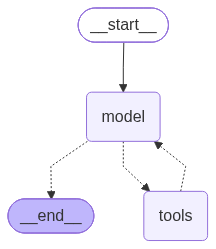

In [4]:
from _graph_viz import show_graph

print(type(agent_b))
show_graph(agent_b)

上面 `show_graph()` 連得上網路時會直接把圖畫出來；離線的話會退回文字版 mermaid，一樣可以貼到 [mermaid.live](https://mermaid.live) 看圖。圖裡一個節點負責呼叫模型（這裡叫 `model`）、一個節點負責執行工具（`tools`），兩者之間來回跳轉。這跟我們在 Tier C 手刻的結構完全相同（只是 Tier C 我們自己把呼叫模型的節點命名為 `agent`），不是巧合——`create_agent` 內部本來就是這樣接的。

## Tier C — 手刻 `StateGraph`

`StateGraph` + `ToolNode` + `tools_condition` 就是 `create_agent` 內部在做的事，只是攤開來讓你自己組一次。`03_langgraph_core.ipynb` 會開始逐一拆解這裡用到的每個元件；這裡的重點是讓你看到「原來三種寫法做的是同一件事」。

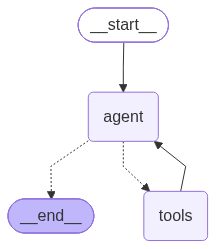

HumanMessage   '台北天氣如何？'                                          tool_calls=None
AIMessage      ''                                                 tool_calls=[{'name': 'get_weather', 'args': {'city': '台北'}, 'id': 'call_1', 'type': 'tool_call'}]
ToolMessage    '台北 is sunny, 28C'                                 tool_calls=None
AIMessage      '台北目前是晴天，28 度。'                                    tool_calls=[]


In [5]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

tier_c_model = scripted_model(
    [
        AIMessage(content="", tool_calls=[{"name": "get_weather", "args": {"city": "台北"}, "id": "call_1"}]),
        AIMessage(content="台北目前是晴天，28 度。"),
    ]
).bind_tools(TOOLS)


def call_model(state: MessagesState) -> dict:
    return {"messages": [tier_c_model.invoke(state["messages"])]}


builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(TOOLS))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")
agent_c = builder.compile()

show_graph(agent_c)

result_c = agent_c.invoke({"messages": QUESTION})
for m in result_c["messages"]:
    print(f"{type(m).__name__:14} {m.content!r:50} tool_calls={getattr(m, 'tool_calls', None)}")

## 小結

| Tier | 程式碼量 | 你能控制什麼 |
|---|---|---|
| A 手刻 while-loop | ~15 行 | 全部都要自己寫，包括之後章節會用到的 checkpoint（存檔）、streaming（逐字輸出）、中斷等能力 |
| B `create_agent` | 1 行 | 用參數快速客製（例如換模型），但內部迴圈的細節看不到也改不到 |
| C `StateGraph` | ~10 行 | 節點、邊、State 的結構全部自己定義；後面章節的 memory / interrupt / streaming / multi-agent 都是在這個能力上疊加出來的 |

選 B 還是 C 看需求：只是要做出一個標準的「查資料再回答」agent，用 B 最快；一旦流程不再是一直線——要插入人工審核關卡、要多個 agent 協作、要在特定步驟中斷等你確認——B 就無法表達，只有 C 才能自訂到這種細節。這正是接下來章節要展開的內容。

## 如果你有 API key：接真模型跑一次
把同樣的工具、同樣的問題，換成 `create_agent(model=get_llm(), ...)`，你會看到結構一模一樣的訊息序列，只是內容是模型真正想出來的，不是照劇本念的。

In [6]:
if has_api_key():
    real_agent = create_agent(model=get_llm(), tools=TOOLS)
    real_result = real_agent.invoke({"messages": QUESTION})
    for m in real_result["messages"]:
        print(f"{type(m).__name__:14} {m.content!r:50} tool_calls={getattr(m, 'tool_calls', None)}")
else:
    print("尚未設定 OPENAI_API_KEY，跳過真模型呼叫（上面的劇本版本已經展示了完整流程）。")

HumanMessage   '台北天氣如何？'                                          tool_calls=None
AIMessage      ''                                                 tool_calls=[{'name': 'get_weather', 'args': {'city': '台北'}, 'id': 'call_sDqagjlxTWIlZrgojQG2tcE5', 'type': 'tool_call'}]
ToolMessage    '台北 is sunny, 28C'                                 tool_calls=None
AIMessage      '台北目前晴天，氣溫約 **28°C**。'                             tool_calls=[]
